In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LassoCV

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train= pd.read_csv('train.csv')

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [43]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Here we can see the categoricals and the continuous and discrete num features

In [44]:
nan_counts = train.isna().sum().sort_values(ascending=False)
nan_pct = (nan_counts / len(train) * 100).round(2)
nan_df = pd.DataFrame({"NaN_count": nan_counts, "NaN_%": nan_pct})
nan_df[nan_df["NaN_count"] > 0]

,NaN_count,NaN_%
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


We have a lot of NaN! According to the Readme file of the dataset, some columns NA mean something, for example NA in the pool feature means the house has no pool. Therefore we need to manage NAs in different ways.

before the train/test split we should do only the meaning-based NA fills:

In [45]:
# categorical cols where NaN means "doesn't exist" (encode as "None")
cat_none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence",
    "MasVnrType", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"
]
train[cat_none_cols] = train[cat_none_cols].fillna("None")


In [46]:
# numeric cols where NaN means "doesn't exist" → fill with 0
num_zero_cols = ["MasVnrArea", "GarageYrBlt", "PoolArea"]
train[num_zero_cols] = train[num_zero_cols].fillna(0)


let's check if there are rare categories in the cat features

In [47]:
cat_cols_all = train.select_dtypes(exclude="number").columns

rare_map = {}

for c in cat_cols_all:
    vc = train[c].value_counts()
    rare = vc[vc < 10]
    if len(rare) > 0:
        rare_map[c] = rare
        print(f"\n{c}")
        print(rare)





Street
Street
Grvl    6
Name: count, dtype: int64

Utilities
Utilities
NoSeWa    1
Name: count, dtype: int64

LotConfig
LotConfig
FR3    4
Name: count, dtype: int64

Neighborhood
Neighborhood
NPkVill    9
Blueste    2
Name: count, dtype: int64

Condition1
Condition1
PosA    8
RRNn    5
RRNe    2
Name: count, dtype: int64

Condition2
Condition2
Feedr     6
Artery    2
RRNn      2
PosN      2
PosA      1
RRAn      1
RRAe      1
Name: count, dtype: int64

HouseStyle
HouseStyle
2.5Fin    8
Name: count, dtype: int64

RoofStyle
RoofStyle
Mansard    7
Shed       2
Name: count, dtype: int64

RoofMatl
RoofMatl
WdShngl    6
WdShake    5
Metal      1
Membran    1
Roll       1
ClyTile    1
Name: count, dtype: int64

Exterior1st
Exterior1st
BrkComm    2
Stone      2
AsphShn    1
ImStucc    1
CBlock     1
Name: count, dtype: int64

Exterior2nd
Exterior2nd
Brk Cmn    7
Stone      5
AsphShn    3
Other      1
CBlock     1
Name: count, dtype: int64

ExterCond
ExterCond
Ex    3
Po    1
Name: count, dtyp

we will merge categories with frequencies below 10 to reduce dimensionality

In [48]:
cat_cols_all = train.select_dtypes(exclude="number").columns

merge_log = {}

for c in cat_cols_all:
    vc = train[c].value_counts()
    rare = vc[vc < 10].index
    if len(rare):
        merge_log[c] = rare
        train[c] = train[c].replace(rare, "Other")


let's split the df by X (inputs) and Y (output= house price)

In [49]:
y = train["SalePrice"]
X = train.drop(["SalePrice", "Id"], axis=1)

X.shape, y.shape

((1460, 79), (1460,))

<Axes: >

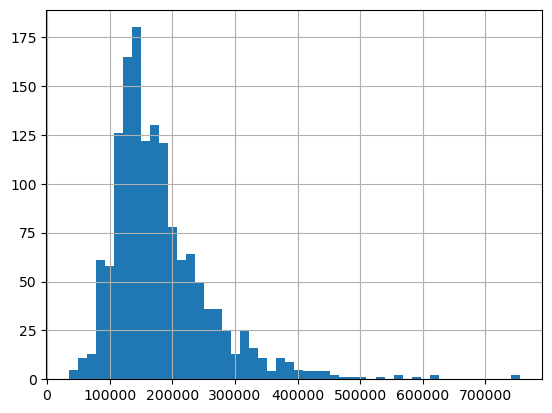

In [50]:

y.hist(bins=50)


Clearly right skewed, let's log transform it

In [51]:
y = np.log1p(y)


<Axes: >

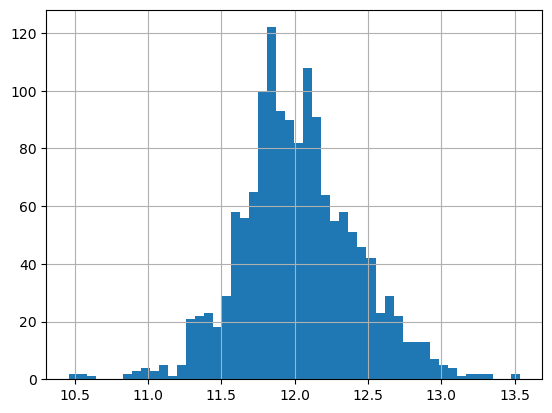

In [52]:
y.hist(bins=50)

In [53]:
print("Skew before:", train["SalePrice"].skew())
print("Skew after: ", y.skew())


Skew before: 1.8828757597682129
Skew after:  0.12134661989685333


Skewness improved a lot!

After transforming the target we will see the features histograms to see if any has extreme skewness

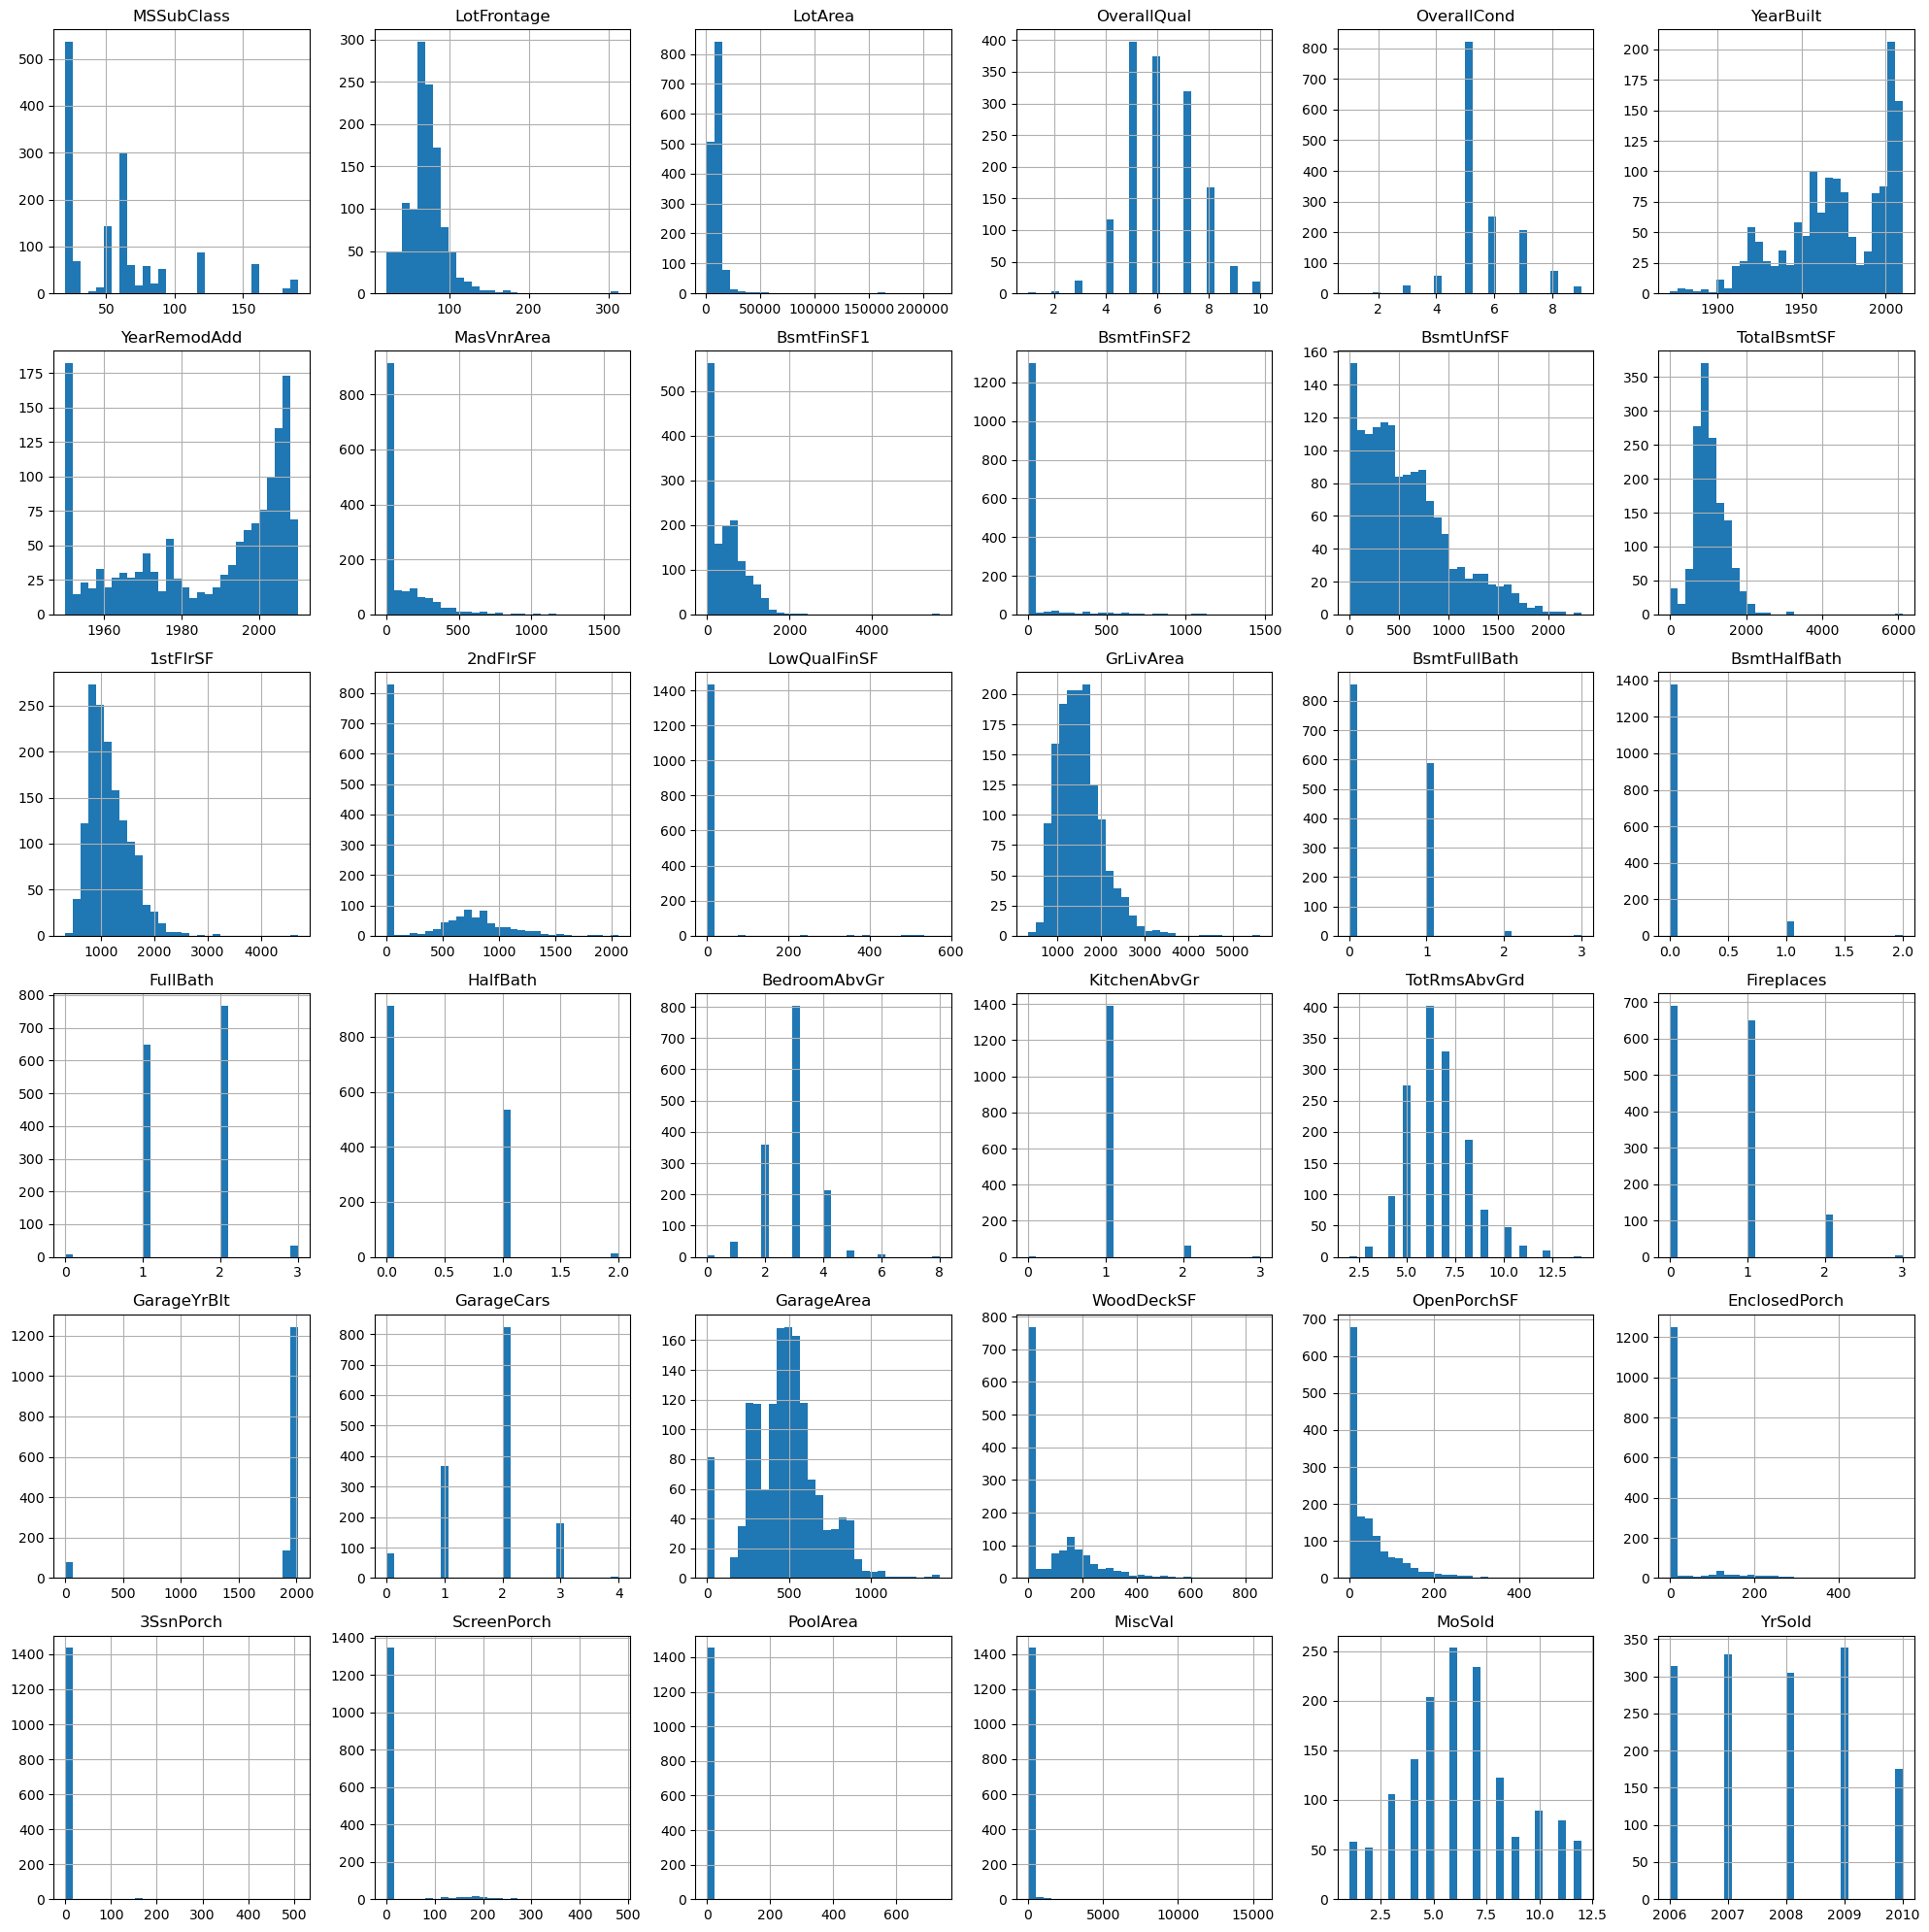

In [54]:
num_cols_all = X.select_dtypes(include="number").columns

# Histograms
X[num_cols_all].hist(bins=30, figsize=(20, 20))
plt.tight_layout()
plt.show()


Many numeric predictors are highly skewed due to the fact that the absence of a feature is coded as 0.

We check which columns have a correlation over 0.8 with other features

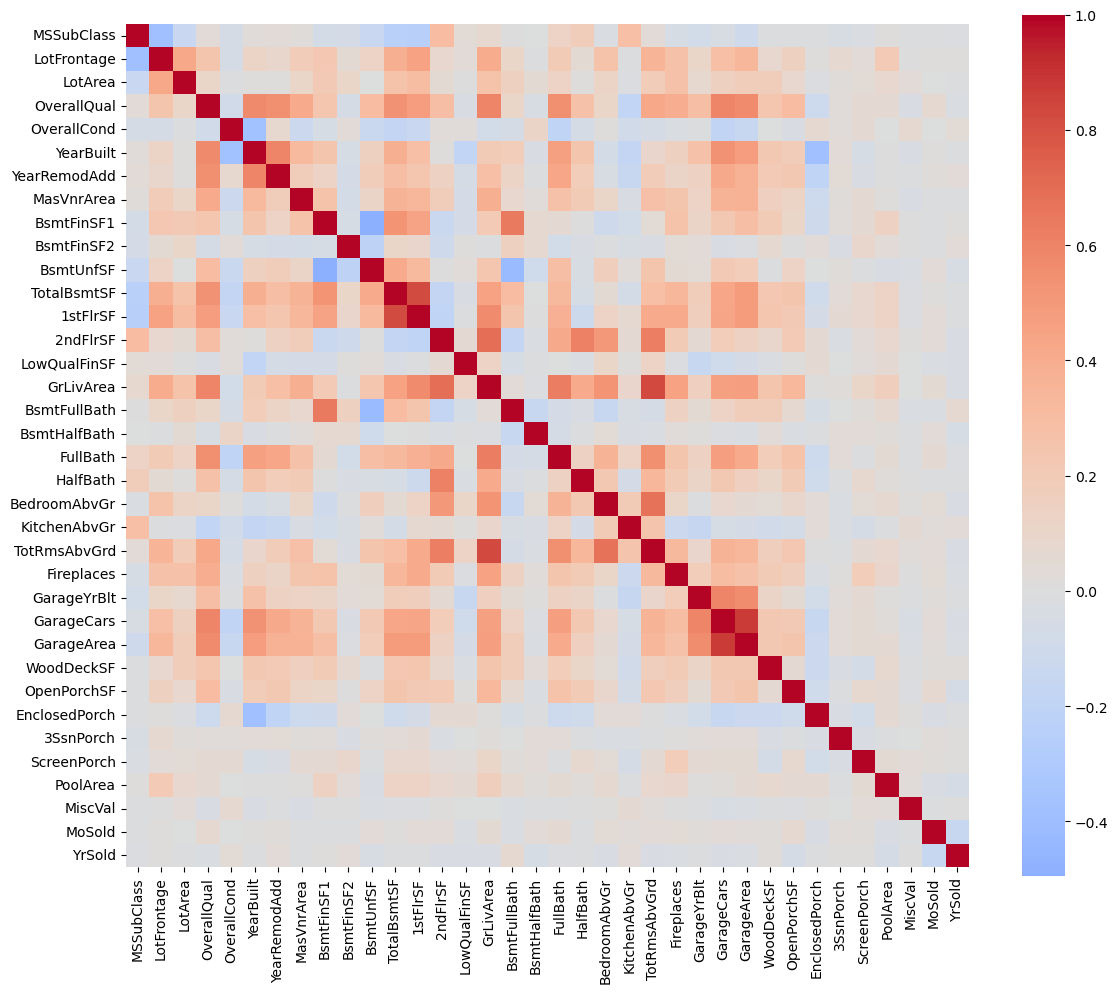

In [55]:
# Correlation heatmap
corr = X[num_cols_all].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.tight_layout()
plt.show()


These are the pairs we need to review

In [56]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={
             "level_0": "feature_1",
             "level_1": "feature_2",
             0: "correlation"
         })
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["correlation"] > 0.8]
high_corr_pairs.sort_values("correlation", ascending=False)


,feature_1,feature_2,correlation
575,GarageCars,GarageArea,0.882475
426,GrLivArea,TotRmsAbvGrd,0.825489
330,TotalBsmtSF,1stFlrSF,0.819530


We removed the aggregate basement size since it is explained by more detailed basement area variables.
We kept square footage over room counts, as it provides a more precise measure of living space.
We kept YearBuilt as the primary temporal feature and removed the redundant garage construction year.
We kept the continuous measure (GarageArea) and removed the discrete proxy (GarageCars).

In [57]:
cols_to_drop = [
    "GarageCars",
    "TotRmsAbvGrd",
    "TotalBsmtSF"
]

X_pruned = X.drop(columns=cols_to_drop)

picked features that have a highly skewed distribution but don't have many zero values (becasue log of 0 is 0)

In [58]:
# create log versions after inspecting histograms (still pre-split)
size_cols = [
    "GrLivArea", "LotArea", "TotalBsmtSF", "LotFrontage", "1stFlrSF", "GrLivArea"]

for c in size_cols:
    if c in X.columns:
        X[f"log_{c}"] = np.log1p(X[c])
num_cols_all = X.select_dtypes(include="number").columns


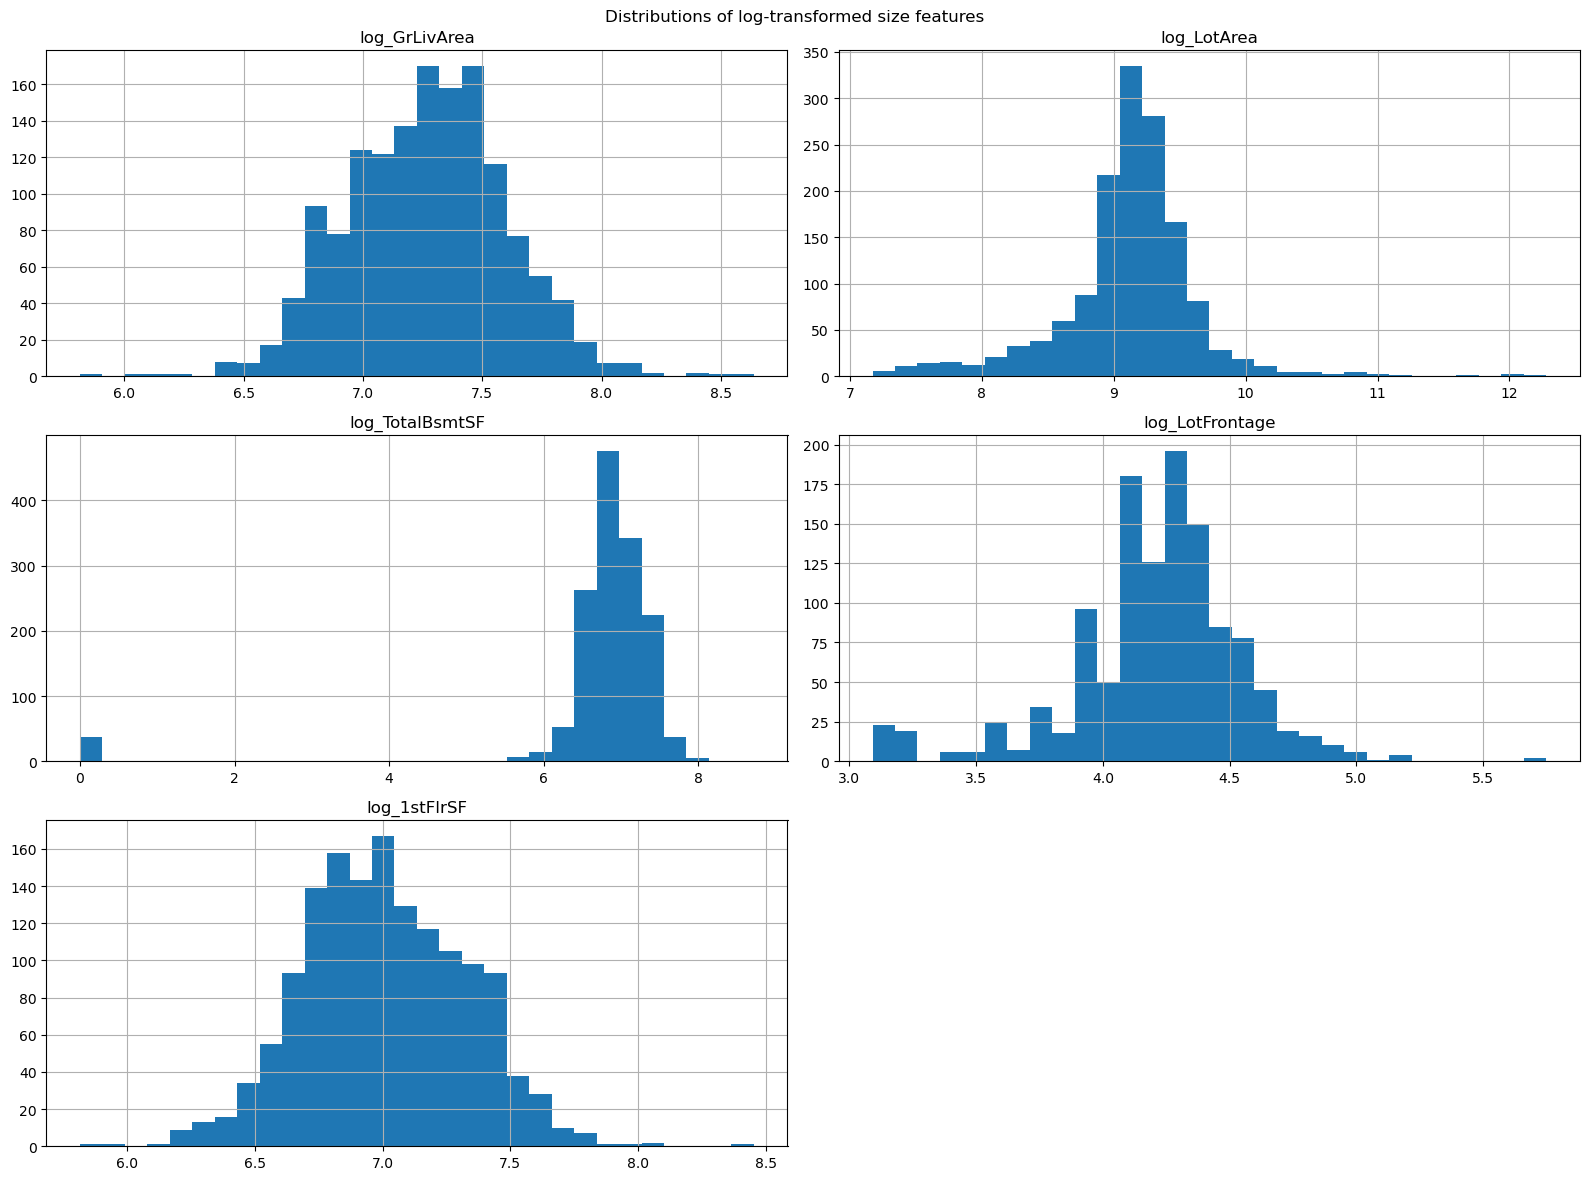

In [59]:
log_cols = [c for c in X.columns if c.startswith("log_")]

X[log_cols].hist(bins=30, figsize=(16, 12))
plt.suptitle("Distributions of log-transformed size features")
plt.tight_layout()
plt.show()


we split train/test

In [60]:
X_train, X_val, y_train, y_val = train_test_split(
    X_pruned, y, test_size=0.2, random_state=42
)



now we do the statistical imputation (on train set only) to fill out remaining NaNs. We will do
most frequent for categoricals and median for the numericals

In [61]:
num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(exclude="number").columns

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[num_cols]),
    columns=num_cols, index=X_train.index
)
X_val_num = pd.DataFrame(
    num_imputer.transform(X_val[num_cols]),
    columns=num_cols, index=X_val.index
)

X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train[cat_cols]),
    columns=cat_cols, index=X_train.index
)
X_val_cat = pd.DataFrame(
    cat_imputer.transform(X_val[cat_cols]),
    columns=cat_cols, index=X_val.index
)

Now we OHE the categoricals

In [62]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train_cat)
X_val_ohe   = ohe.transform(X_val_cat)


we will now do z-score standardization to put predictors in comparable scales

In [63]:
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_val_num_scaled = scaler.transform(X_val_num)


Now we put back together the OHE and the numeric features

In [64]:
X_train_final = np.hstack([X_train_num_scaled, X_train_ohe])
X_val_final = np.hstack([X_val_num_scaled, X_val_ohe])

print("Train shape:", X_train_final.shape)
print("Val shape:  ", X_val_final.shape)
print("NaNs train:", int(np.isnan(X_train_final).sum()))
print("NaNs val:  ", int(np.isnan(X_val_final).sum()))


Train shape: (1168, 256)
Val shape:   (292, 256)
NaNs train: 0
NaNs val:   0


Now we use LassoCV. we want penalties on large (complex) coefficients and Lasso also helps with additional feature selection.

In [65]:
lasso = LassoCV(cv=10, random_state=42, max_iter=20000)
lasso.fit(X_train_final, y_train)

print("Best alpha:", float(lasso.alpha_))
print("Train R^2:", float(lasso.score(X_train_final, y_train)))
print("Val R^2:  ", float(lasso.score(X_val_final, y_val)))


Best alpha: 0.0008378717795071594
Train R^2: 0.9036412915333373
Val R^2:   0.8931400995821628


The model explains approximately 89% of the variation in log house prices in the validation set.

let's see if lasso CV dropped any features

In [66]:
coef = lasso.coef_

n_zero = np.sum(coef == 0)
n_total = coef.size

print(f"Dropped features: {n_zero} / {n_total}")

# feature names in correct order
feature_names = np.r_[
    num_cols,
    ohe.get_feature_names_out(cat_cols)
]

dropped = feature_names[lasso.coef_ == 0]
kept = feature_names[lasso.coef_ != 0]

len(dropped), dropped[:20]


Dropped features: 163 / 256


(163,
 array(['2ndFlrSF', 'OpenPorchSF', 'MoSold', 'MSZoning_C (all)',
        'MSZoning_FV', 'MSZoning_RH', 'Street_Other', 'Street_Pave',
        'Alley_Grvl', 'Alley_None', 'Alley_Pave', 'LotShape_IR1',
        'LotShape_Reg', 'LandContour_Low', 'LandContour_Lvl',
        'Utilities_AllPub', 'Utilities_Other', 'LotConfig_Corner',
        'LotConfig_FR2', 'LotConfig_Other'], dtype=object))

Cross-validation selected a small penalty parameter (aplha= 0.0008), implying that only mild regularization is required. However Lasso also does a useful feature selection by shrinking many coefficients to zero.

In [68]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": lasso.coef_
})

coef_df = coef_df.reindex(
    coef_df["coef"].abs().sort_values(ascending=False).index
)


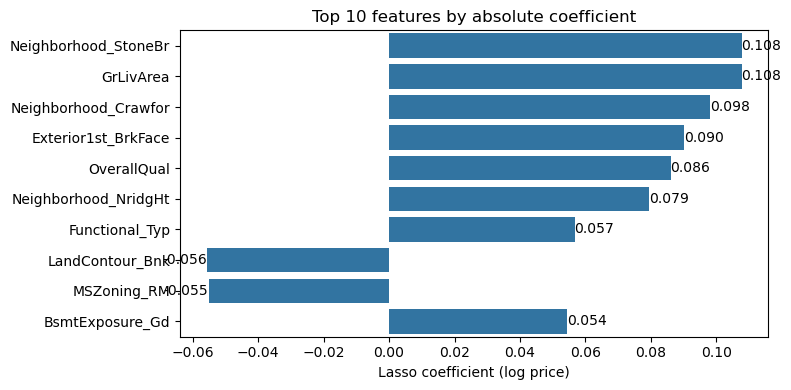

In [71]:
top10 = coef_df.head(10).iloc[::1]

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=top10["coef"], y=top10["feature"])

for i, v in enumerate(top10["coef"]):
    ax.text(
        v,
        i,
        f"{v:.3f}",
        va="center",
        ha="left" if v > 0 else "right"
    )

plt.xlabel("Lasso coefficient (log price)")
plt.ylabel("")
plt.title("Top 10 features by absolute coefficient")
plt.tight_layout()
plt.show()



The results are economically intuitive, stable, and interpretable: house prices are primarily driven by size and location, with additional adjustments from quality and zoning characteristics.

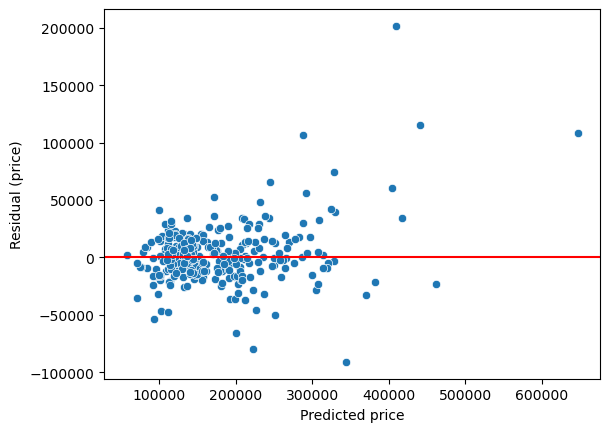

In [72]:
y_pred = lasso.predict(X_val_final)

y_val_price  = np.expm1(y_val)   
y_pred_price = np.expm1(y_pred)

resid_price = y_val_price - y_pred_price

sns.scatterplot(x=y_pred_price, y=resid_price)
plt.axhline(0, color="red")
plt.xlabel("Predicted price")
plt.ylabel("Residual (price)")
plt.show()



No residuals structure. except for some isolated cases, variance doesn't seem to increase systematically.

In [73]:
resid_price.skew()


np.float64(2.055610602437657)

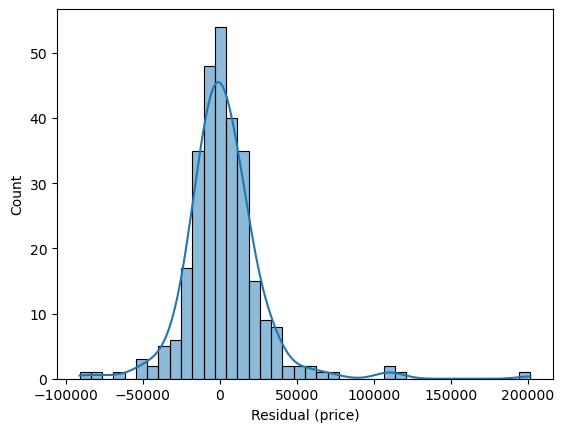

Residual skew (price): 2.055610602437657


In [74]:
sns.histplot(resid_price, bins=40, kde=True)
plt.xlabel("Residual (price)")
plt.ylabel("Count")
plt.show()

print("Residual skew (price):", pd.Series(resid_price).skew())

centered in zero and mostly normal distribution. except for sosme high errors for high-cost properties.

In [82]:
bins = pd.qcut(y_val_price, 5, duplicates="drop")
pd.Series(resid_price).groupby(bins, observed=True).agg(
    ["count", "mean"]
)

,count,mean
SalePrice,,
"(35310.999, 119000.0]",60,-8924.457584
"(119000.0, 141000.0]",58,1404.912038
"(141000.0, 175000.0]",58,238.886635
"(175000.0, 234800.0]",57,-644.947280
"(234800.0, 755000.0]",59,19113.171161


Errors tend to be higher for high house prices than for medium and lower prices.


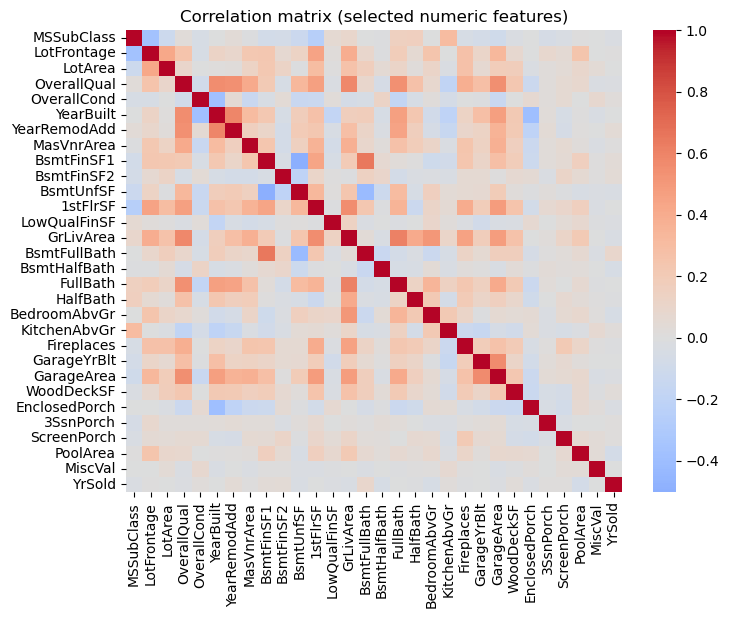

In [76]:
kept_num = [c for c in kept if c in num_cols]

corr_num = X_train[kept_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_num, cmap="coolwarm", center=0)
plt.title("Correlation matrix (selected numeric features)")
plt.show()


Correlation between predictors doesn't seem to be above 0.5

let's check for the top 10 houses with highest error:

In [77]:
error_df = X_val.copy()
error_df["y_true_price"] = y_val_price
error_df["y_pred_price"] = y_pred_price
error_df["resid_price"]  = resid_price
error_df["abs_resid"]    = np.abs(resid_price)

top10_errors = error_df.sort_values("abs_resid", ascending=False).head(10)
top10_errors[["y_true_price", "y_pred_price", "resid_price"]]


,y_true_price,y_pred_price,resid_price
898,611657.0,409960.539578,201696.460422
1046,556581.0,440981.676821,115599.323179
691,755000.0,646439.577714,108560.422286
774,395000.0,288154.656937,106845.343063
581,253293.0,344335.258936,-91042.258936
588,143000.0,222500.385941,-79500.385941
231,403000.0,328333.221744,74666.778256
218,311500.0,245449.524091,66050.475909
628,135000.0,200441.557572,-65441.557572
1243,465000.0,404486.075885,60513.924115


let's characterize them

In [78]:
cols_to_inspect = [
    "GrLivArea", "OverallQual", "YearBuilt",
    "Neighborhood", "MSZoning"
]

top10_errors[cols_to_inspect]


,GrLivArea,OverallQual,YearBuilt,Neighborhood,MSZoning
898,2364,9,2009,NridgHt,RL
1046,2868,9,2005,StoneBr,RL
691,4316,10,1994,NoRidge,RL
774,1973,8,2006,NridgHt,RL
581,2042,8,2008,NridgHt,RL
588,1473,5,1968,ClearCr,RL
231,2794,8,1995,NoRidge,RL
218,1954,7,1939,Crawfor,RL
628,2080,5,1969,NAmes,RL
1243,2076,10,2006,NridgHt,RL


In [79]:
key_vars = ["GrLivArea", "OverallQual", "YearBuilt"]

quantiles = {}

for v in key_vars:
    quantiles[v] = pd.qcut(
        X_val[v],
        q=10,
        labels=False,
        duplicates="drop"
    ) + 1   # cuantiles 1–10

quantile_df = pd.DataFrame(quantiles, index=X_val.index)
quantile_df.loc[top10_errors.index]


,GrLivArea,OverallQual,YearBuilt
898,10,6,10
1046,10,6,9
691,10,6,7
774,9,5,9
581,9,5,10
588,6,2,5
231,10,5,7
218,9,4,2
628,9,2,5
1243,9,6,9


Large residuals are concentrated among properties in the top quantiles of living area. Except for nuber ID 588 which is the only one located at CLearCr.

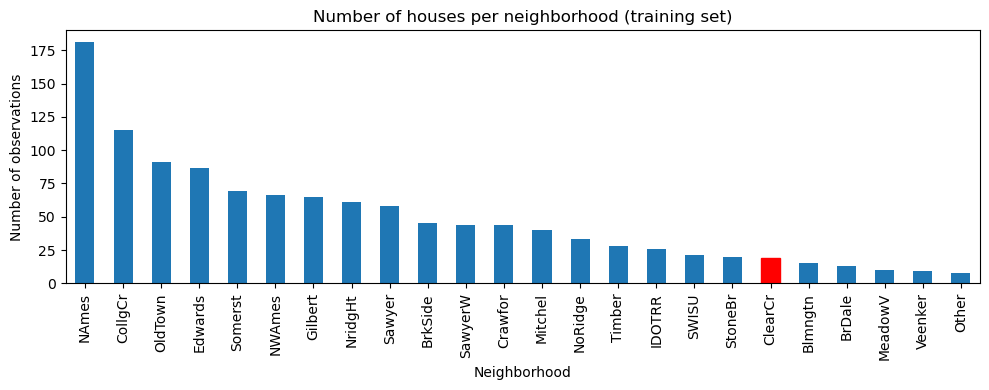

In [80]:
counts = X_train["Neighborhood"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
ax = counts.plot(kind="bar")

# highlight ClearCr
for i, n in enumerate(counts.index):
    if n == "ClearCr":
        ax.patches[i].set_color("red")

plt.ylabel("Number of observations")
plt.xlabel("Neighborhood")
plt.title("Number of houses per neighborhood (training set)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


The small number of observations in ClearCr leads to an unstable neighborhood effect, which helps explain part of the large residual observed for this property.